In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import re
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pickle
import os 
import warnings 

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')


print("All libraries imported successfully")

All libraries imported successfully


In [2]:
df= pd.read_csv('data/netflix_titles.csv')

print(f'Dataset shape : {df.shape}')
print(f'Total titles(rows) : {df.shape[0]}')
print(f"Total columns : {df.shape[1]}")
print("\nColumn names : ")
print(df.columns.tolist())
print("\nFirst 3 rows : ")
df.head(3)


Dataset shape : (8807, 12)
Total titles(rows) : 8807
Total columns : 12

Column names : 
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

First 3 rows : 


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


In [3]:
print("=== DATA TYPES ===")
print(df.dtypes)

print("\n=== BASIC STATISTICS ===")
print(df.describe(include = 'all'))

=== DATA TYPES ===
show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

=== BASIC STATISTICS ===
       show_id   type                 title       director  \
count     8807   8807                  8807           6173   
unique    8807      2                  8807           4528   
top         s1  Movie  Dick Johnson Is Dead  Rajiv Chilaka   
freq         1   6131                     1             19   
mean       NaN    NaN                   NaN            NaN   
std        NaN    NaN                   NaN            NaN   
min        NaN    NaN                   NaN            NaN   
25%        NaN    NaN                   NaN            NaN   
50%        NaN    NaN                   NaN            NaN   
75%        NaN    NaN                   NaN            Na

In [4]:
print('=== Missing Values ===\n')
missing = df.isnull().sum()
missing_percent = (df.isnull().sum()/len(df))*100

missing_df=pd.DataFrame({'Missing count' : missing,
                         'Percentage' : missing_percent.round(2)
                         })
missing_df=missing_df[missing_df['Missing count']>0]
missing_df=missing_df.sort_values('Percentage' , ascending=False)
print(missing_df)


=== Missing Values ===

            Missing count  Percentage
director             2634       29.91
country               831        9.44
cast                  825        9.37
date_added             10        0.11
rating                  4        0.05
duration                3        0.03


<function matplotlib.pyplot.show(close=None, block=None)>

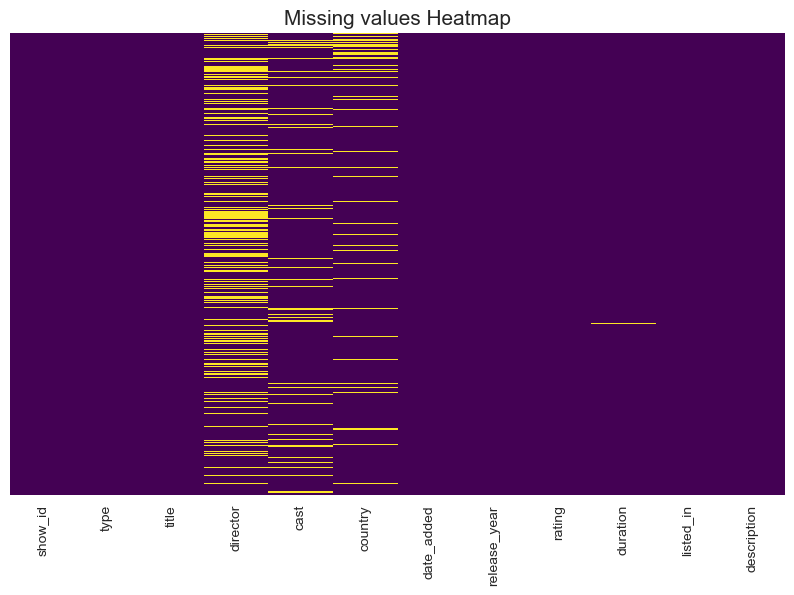

In [5]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df.isnull(),
    yticklabels=False,
    cbar=False,
    cmap='viridis')
plt.title('Missing values Heatmap', fontsize =15)
plt.savefig('images/missing_values.png',bbox_inches='tight')
plt.show

In [6]:
df_clean= df.copy()

df_clean['director'] = df_clean['director'].fillna('Unknown')
df_clean['cast'] = df_clean['cast'].fillna('Unknown')
df_clean['country'] = df_clean['country'].fillna('Unknown')
df_clean['rating'] = df_clean['rating'].fillna('Unknown')
df_clean['date_added'] = df_clean['date_added'].fillna('Unknown')


df_clean = df_clean.dropna(subset=['duration'])

df_clean['date_added'] = df_clean['date_added'].str.strip()

print("Missing values after cleaning : ")
print(df_clean.isnull().sum())
print(f'\nShape after cleaning : {df_clean.shape}')
print(f'Shape before cleaning : {df.shape}')

Missing values after cleaning : 
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

Shape after cleaning : (8804, 12)
Shape before cleaning : (8807, 12)


In [7]:
df_clean['date_added']=pd.to_datetime(
    df_clean['date_added'],
    errors='coerce'
)

df_clean['year_added']=df_clean['date_added'].dt.year
df_clean['month_added']=df_clean['date_added'].dt.month
df_clean['month_name']=df_clean['date_added'].dt.strftime('%B')

print(df_clean[['date_added', 'year_added', 
                'month_added', 'month_name']].head(10))


  date_added  year_added  month_added month_name
0 2021-09-25      2021.0          9.0  September
1 2021-09-24      2021.0          9.0  September
2 2021-09-24      2021.0          9.0  September
3 2021-09-24      2021.0          9.0  September
4 2021-09-24      2021.0          9.0  September
5 2021-09-24      2021.0          9.0  September
6 2021-09-24      2021.0          9.0  September
7 2021-09-24      2021.0          9.0  September
8 2021-09-24      2021.0          9.0  September
9 2021-09-24      2021.0          9.0  September


In [8]:
movies = df_clean[df_clean['type'] == 'Movie'].copy()
tvshows = df_clean[df_clean['type'] == 'TV Show'].copy()

movies['duration_mins'] = movies['duration'].str.replace(
    ' min', '', regex=False).astype(int)

tvshows['duration_seasons'] = tvshows['duration'].str.replace(
    ' Seasons', '', regex=False).str.replace(
    ' Season', '', regex=False).astype(int)

print(f"Total Movies: {len(movies)}")
print(f"Total TV Shows: {len(tvshows)}")
print(f"\nMovie duration sample:")
print(movies[['title', 'duration', 'duration_mins']].head())

Total Movies: 6128
Total TV Shows: 2676

Movie duration sample:
                               title duration  duration_mins
0               Dick Johnson Is Dead   90 min             90
6   My Little Pony: A New Generation   91 min             91
7                            Sankofa  125 min            125
9                       The Starling  104 min            104
12                      Je Suis Karl  127 min            127


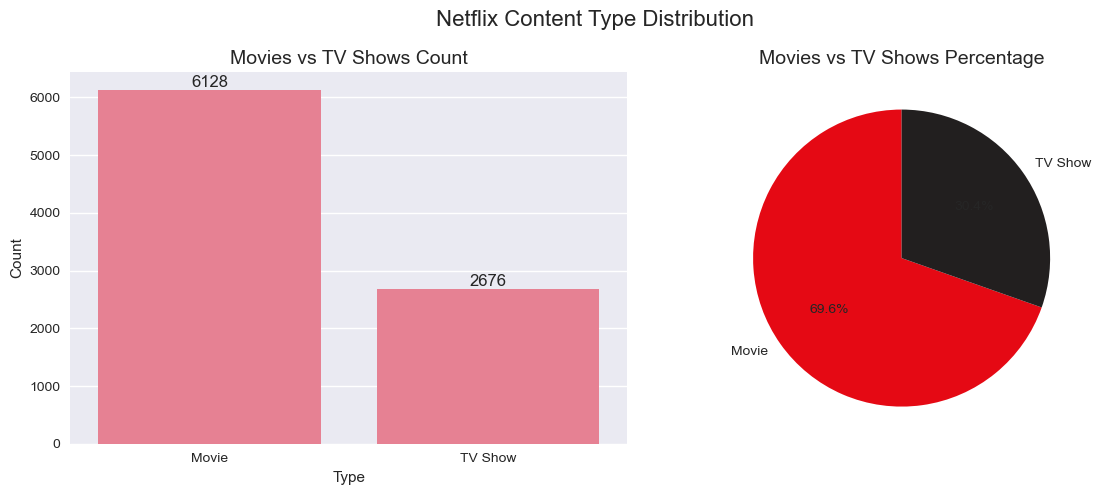

Movies: 6128 (69.6%)
TV Shows: 2676 (30.4%)


In [9]:
type_counts = df_clean['type'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x=type_counts.index, y=type_counts.values, ax=ax1)
ax1.set_title('Movies vs TV Shows Count', fontsize=14)
ax1.set_xlabel('Type')
ax1.set_ylabel('Count')
for i, v in enumerate(type_counts.values):
    ax1.text(i, v + 50, str(v), ha='center', fontsize=12)

ax2.pie(
    type_counts.values,
    labels=type_counts.index,
    autopct='%1.1f%%',
    colors=['#E50914', '#221F1F'],
    startangle=90
)
ax2.set_title('Movies vs TV Shows Percentage', fontsize=14)

plt.suptitle('Netflix Content Type Distribution', fontsize=16)
plt.tight_layout()
plt.savefig('images/content_type.png', bbox_inches='tight')
plt.show()

print(f"Movies: {type_counts['Movie']} ({type_counts['Movie']/len(df_clean)*100:.1f}%)")
print(f"TV Shows: {type_counts['TV Show']} ({type_counts['TV Show']/len(df_clean)*100:.1f}%)")

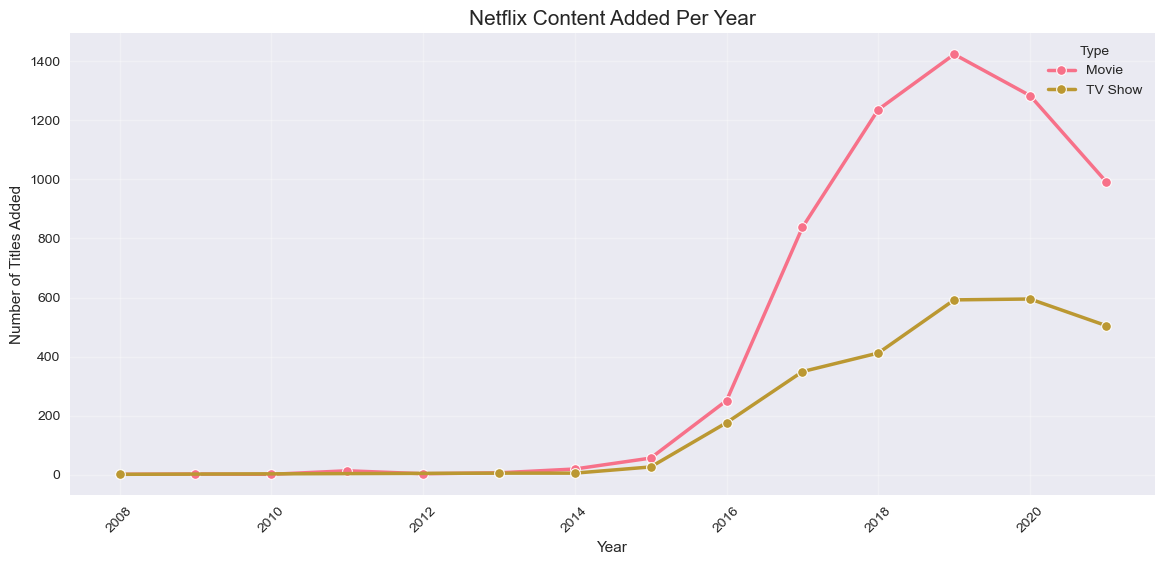

In [10]:
yearly = df_clean[df_clean['year_added'].notna()]
yearly_counts = yearly.groupby(
    ['year_added', 'type']).size().reset_index(name='count')

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=yearly_counts,
    x='year_added',
    y='count',
    hue='type',
    marker='o',
    linewidth=2.5
)
plt.title('Netflix Content Added Per Year', fontsize=15)
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.xticks(rotation=45)
plt.legend(title='Type')
plt.grid(True, alpha=0.3)
plt.savefig('images/content_per_year.png', bbox_inches='tight')
plt.show()

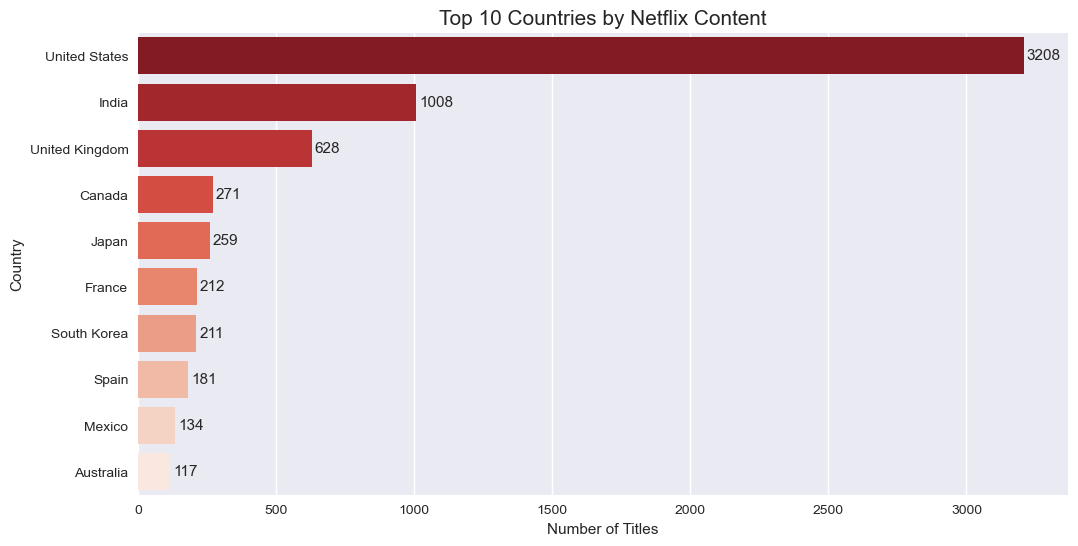

In [11]:
df_clean['primary_country'] = df_clean['country'].str.split(
    ',').str[0].str.strip()

country_data = df_clean[df_clean['primary_country'] != 'Unknown']
country_counts = country_data['primary_country'].value_counts().head(10)

plt.figure(figsize=(12, 6))
bars = sns.barplot(
    x=country_counts.values,
    y=country_counts.index,
    palette='Reds_r'
)

for i, v in enumerate(country_counts.values):
    bars.text(v + 10, i, str(v), va='center', fontsize=11)

plt.title('Top 10 Countries by Netflix Content', fontsize=15)
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.savefig('images/top_countries.png', bbox_inches='tight')
plt.show()

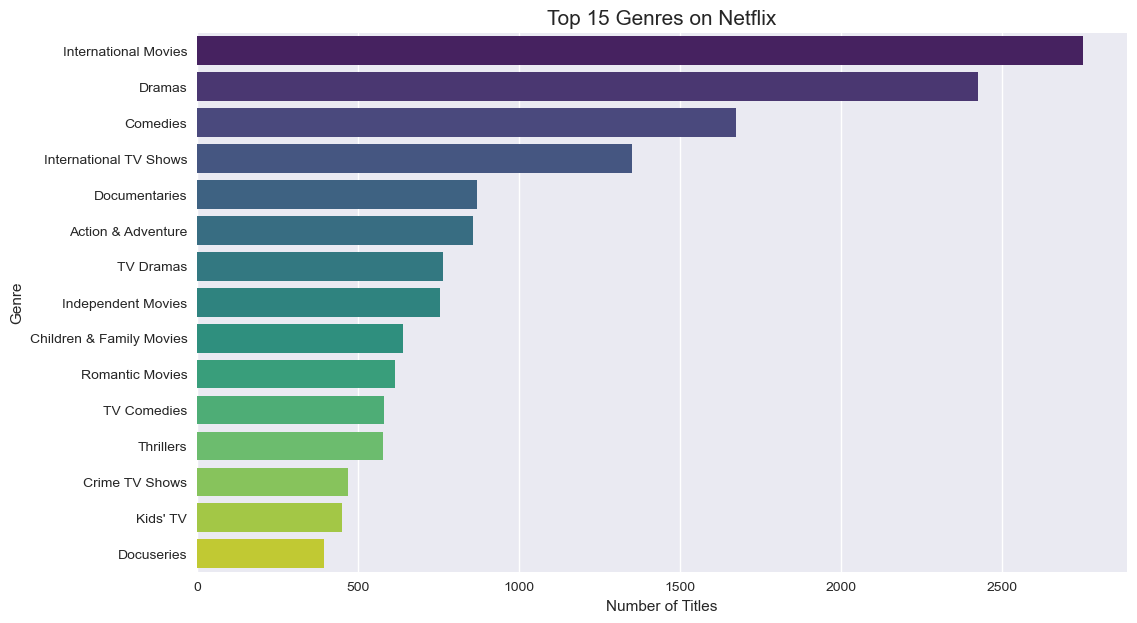

In [12]:
all_genres = []
for genres in df_clean['listed_in']:
    genre_list = [g.strip() for g in genres.split(',')]
    all_genres.extend(genre_list)

genre_counts = Counter(all_genres)
genre_df = pd.DataFrame(
    genre_counts.most_common(15),
    columns=['Genre', 'Count']
)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=genre_df,
    x='Count',
    y='Genre',
    palette='viridis'
)
plt.title('Top 15 Genres on Netflix', fontsize=15)
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.savefig('images/top_genres.png', bbox_inches='tight')
plt.show()

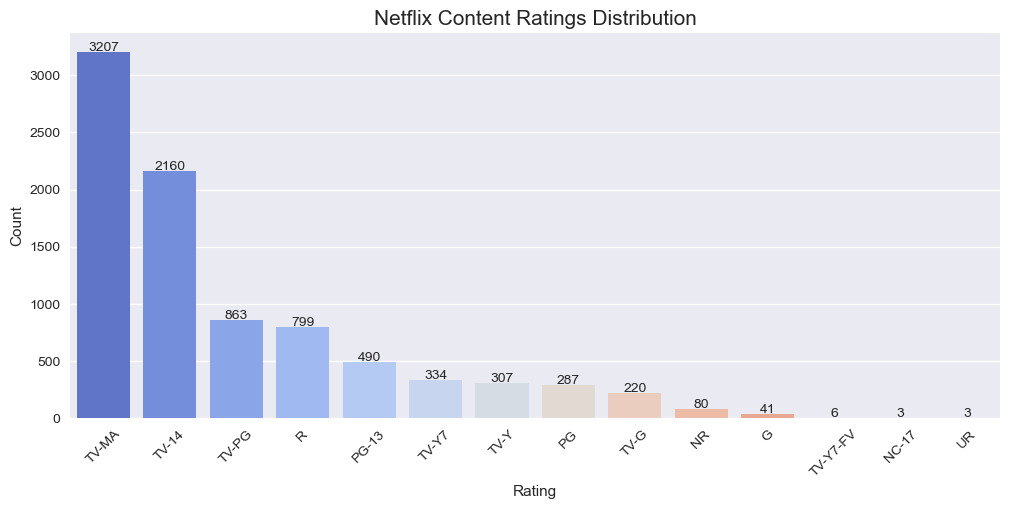


Rating Guide:
TV-MA  = Adults only (17+)
TV-14  = Parents strongly cautioned (14+)
TV-PG  = Parental guidance suggested
R      = Restricted (17+) - Movies
PG-13  = Parents cautioned (13+) - Movies
PG     = Parental guidance - Movies
TV-G   = General audience all ages


In [13]:
rating_counts = df_clean[
    df_clean['rating'] != 'Unknown']['rating'].value_counts()

plt.figure(figsize=(12, 5))
sns.barplot(
    x=rating_counts.index,
    y=rating_counts.values,
    palette='coolwarm'
)
plt.title('Netflix Content Ratings Distribution', fontsize=15)
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)

for i, v in enumerate(rating_counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontsize=10)

plt.savefig('images/ratings_distribution.png', bbox_inches='tight')
plt.show()

print("\nRating Guide:")
print("TV-MA  = Adults only (17+)")
print("TV-14  = Parents strongly cautioned (14+)")
print("TV-PG  = Parental guidance suggested")
print("R      = Restricted (17+) - Movies")
print("PG-13  = Parents cautioned (13+) - Movies")
print("PG     = Parental guidance - Movies")
print("TV-G   = General audience all ages")

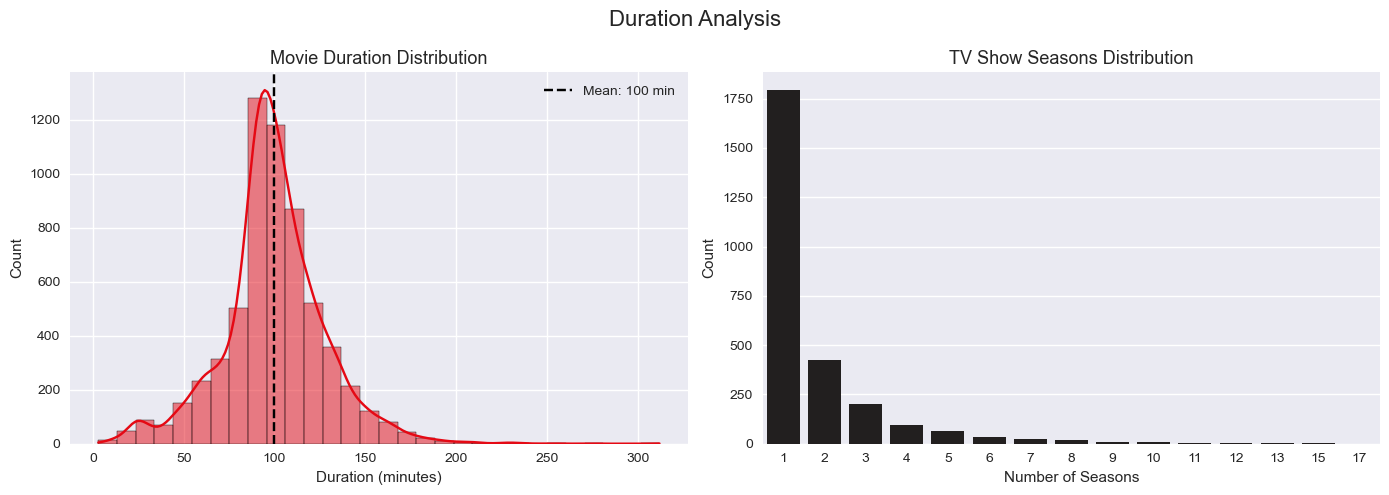

Average movie duration: 100 minutes
Shortest: 3 minutes
Longest: 312 minutes


In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    movies['duration_mins'],
    bins=30,
    kde=True,
    ax=ax1,
    color='#E50914'
)
ax1.set_title('Movie Duration Distribution', fontsize=13)
ax1.set_xlabel('Duration (minutes)')
ax1.set_ylabel('Count')
ax1.axvline(
    movies['duration_mins'].mean(),
    color='black',
    linestyle='--',
    label=f"Mean: {movies['duration_mins'].mean():.0f} min"
)
ax1.legend()

tvshow_seasons = tvshows['duration_seasons'].value_counts().sort_index()
sns.barplot(
    x=tvshow_seasons.index,
    y=tvshow_seasons.values,
    ax=ax2,
    color='#221F1F'
)
ax2.set_title('TV Show Seasons Distribution', fontsize=13)
ax2.set_xlabel('Number of Seasons')
ax2.set_ylabel('Count')

plt.suptitle('Duration Analysis', fontsize=16)
plt.tight_layout()
plt.savefig('images/duration_analysis.png', bbox_inches='tight')
plt.show()

print(f"Average movie duration: {movies['duration_mins'].mean():.0f} minutes")
print(f"Shortest: {movies['duration_mins'].min()} minutes")
print(f"Longest: {movies['duration_mins'].max()} minutes")

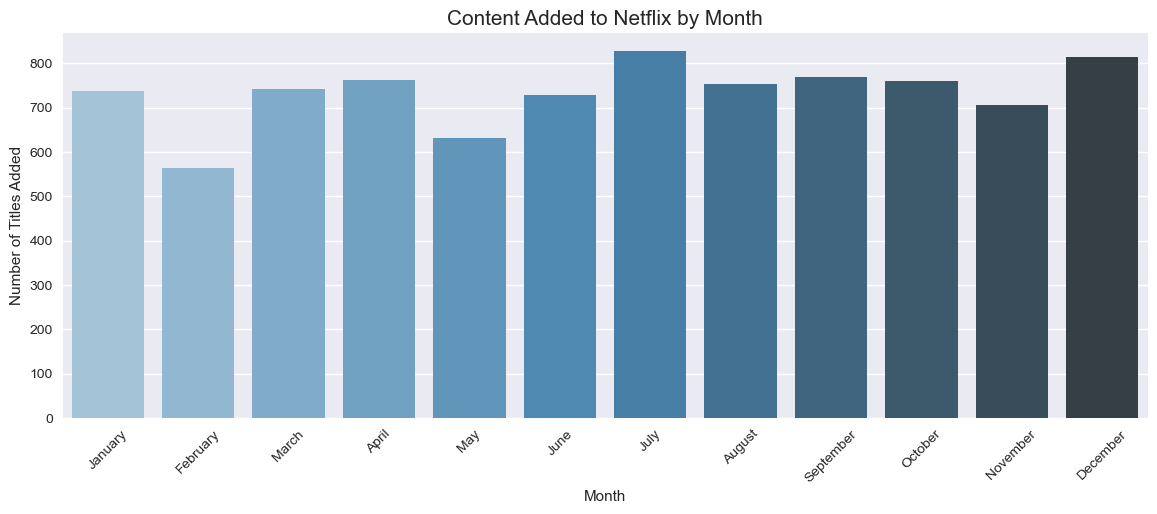

Most content added in: July


In [15]:
month_order = ['January', 'February', 'March', 'April',
               'May', 'June', 'July', 'August',
               'September', 'October', 'November', 'December']

month_counts = df_clean[
    df_clean['month_name'].notna()]['month_name'].value_counts()
month_counts = month_counts.reindex(month_order)

plt.figure(figsize=(14, 5))
sns.barplot(
    x=month_counts.index,
    y=month_counts.values,
    palette='Blues_d'
)
plt.title('Content Added to Netflix by Month', fontsize=15)
plt.xlabel('Month')
plt.ylabel('Number of Titles Added')
plt.xticks(rotation=45)
plt.savefig('images/content_by_month.png', bbox_inches='tight')
plt.show()

best_month = month_counts.idxmax()
print(f"Most content added in: {best_month}")

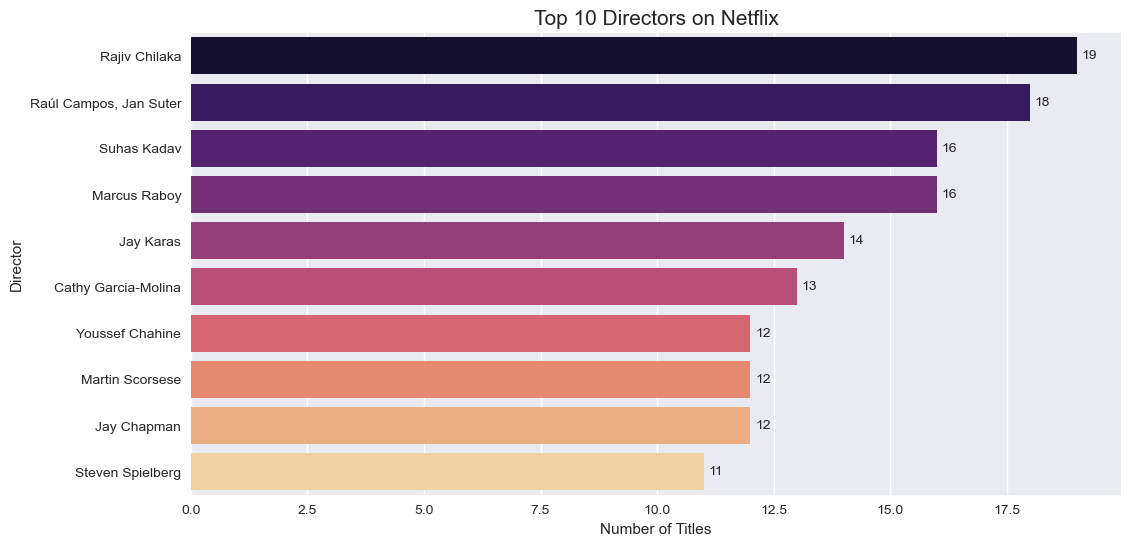

In [16]:
director_counts = df_clean[
    df_clean['director'] != 'Unknown'
]['director'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=director_counts.values,
    y=director_counts.index,
    palette='magma'
)
plt.title('Top 10 Directors on Netflix', fontsize=15)
plt.xlabel('Number of Titles')
plt.ylabel('Director')

for i, v in enumerate(director_counts.values):
    plt.text(v + 0.1, i, str(v), va='center')

plt.savefig('images/top_directors.png', bbox_inches='tight')
plt.show()

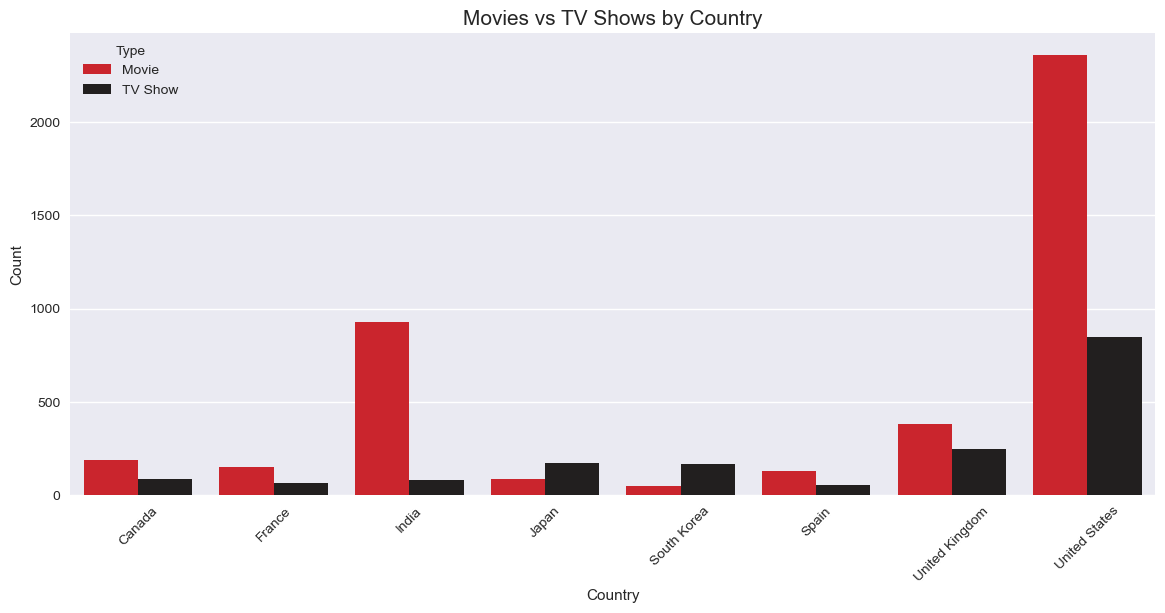

In [17]:
top_countries = df_clean[
    df_clean['primary_country'] != 'Unknown'
]['primary_country'].value_counts().head(8).index.tolist()

country_type = df_clean[
    df_clean['primary_country'].isin(top_countries)
].groupby(['primary_country', 'type']).size().reset_index(name='count')

plt.figure(figsize=(14, 6))
sns.barplot(
    data=country_type,
    x='primary_country',
    y='count',
    hue='type',
    palette=['#E50914', '#221F1F']
)
plt.title('Movies vs TV Shows by Country', fontsize=15)
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Type')
plt.savefig('images/country_type.png', bbox_inches='tight')
plt.show()

In [ ]:
print("=" * 55)
print("  NETFLIX DATA ANALYSIS — KEY FINDINGS")
print("=" * 55)

total = len(df_clean)
movie_pct = len(movies)/total*100
tv_pct = len(tvshows)/total*100

print(f"\nCONTENT:")
print(f"  Total titles: {total}")
print(f"  Movies:    {len(movies)} ({movie_pct:.1f}%)")
print(f"  TV Shows:  {len(tvshows)} ({tv_pct:.1f}%)")

top_country = df_clean[
    df_clean['primary_country'] != 'Unknown'
]['primary_country'].value_counts().index[0]
print(f"\nTOP COUNTRY: {top_country}")

print(f"\nMOVIES:")
print(f"  Average duration: {movies['duration_mins'].mean():.0f} minutes")
print(f"  Shortest: {movies['duration_mins'].min()} min")
print(f"  Longest:  {movies['duration_mins'].max()} min")

print(f"\nTV SHOWS:")
most_common_seasons = tvshows['duration_seasons'].mode()[0]
print(f"  Most common: {most_common_seasons} season(s)")

peak_year = int(df_clean['year_added'].value_counts().index[0])
print(f"\nGROWTH: Most content added in {peak_year}")

print(f"\nTOP GENRE: {genre_df.iloc[0]['Genre']} ({genre_df.iloc[0]['Count']} titles)")
print("=" * 55)